In [1]:
from __future__ import annotations

import logging
import math
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import ttest_rel
from tqdm import tqdm

from config import dir_config
from src.ddm.utils import build_stimulus, prepare_data, load_model
from src.utils import pmf_utils

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

## Setup

In [2]:
cwd = Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)

processed_dir = Path(dir_config.data.processed)
ddm_dir = processed_dir / "ddm"

behavior_df = pd.read_csv(ddm_dir / "behavior_data.csv")
metadata = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv")

best_model = "leak-1_tc-1"
model_dir = ddm_dir / best_model

## Data Loading

### Session Classification

In [3]:
model_files = [load_model(model_path) for model_path in tqdm(model_dir.glob("*.pkl"), unit="file")]

200file [01:38,  2.03file/s]


In [4]:
asm_controls = {}
trem_off_meds, trem_on_meds = {}, {}
brady_off_meds, brady_on_meds = {}, {}

In [5]:
asm_controls["session_ids"] = metadata[metadata["is_pd"] == 0]["session_id"].unique()
trem_off_meds["session_ids"] = metadata[(metadata["trem_vs_brady_type"] == "tremor") & (metadata["treatment"] == "OFF")]["session_id"].unique()
trem_on_meds["session_ids"] = metadata[(metadata["trem_vs_brady_type"] == "tremor") & (metadata["treatment"] == "ON")]["session_id"].unique()
brady_off_meds["session_ids"] = metadata[(metadata["trem_vs_brady_type"] == "bradykinetic") & (metadata["treatment"] == "OFF")]["session_id"].unique()
brady_on_meds["session_ids"] = metadata[(metadata["trem_vs_brady_type"] == "bradykinetic") & (metadata["treatment"] == "ON")]["session_id"].unique()

print(f"ASM healthy controls: {len(asm_controls['session_ids'])}")
print(f"Tremor off meds: {len(trem_off_meds['session_ids'])}")
print(f"Tremor on meds: {len(trem_on_meds['session_ids'])}")
print(f"Bradykinetic off meds: {len(brady_off_meds['session_ids'])}")
print(f"Bradykinetic on meds: {len(brady_on_meds['session_ids'])}")

ASM healthy controls: 18
Tremor off meds: 11
Tremor on meds: 11
Bradykinetic off meds: 10
Bradykinetic on meds: 10


In [6]:
# collect models for each group
asm_controls["models"] = [model for model in model_files if model["job"]["session_id"] in asm_controls["session_ids"]]
trem_off_meds["models"] = [model for model in model_files if model["job"]["session_id"] in trem_off_meds["session_ids"]]
trem_on_meds["models"] = [model for model in model_files if model["job"]["session_id"] in trem_on_meds["session_ids"]]
brady_off_meds["models"] = [model for model in model_files if model["job"]["session_id"] in brady_off_meds["session_ids"]]
brady_on_meds["models"] = [model for model in model_files if model["job"]["session_id"] in brady_on_meds["session_ids"]]

## Functions

In [7]:
def get_simulated_data(model_struct, behavior_df):
    session_data = prepare_data(
        behavior_df,
        session_id=model_struct["job"]["session_id"],
        color=int(model_struct["job"]["color"]),
    )
    stimulus = build_stimulus(session_data)
    sim_data = model_struct["model"].simulate(stimulus=stimulus, params=model_struct["results"]["parameters"], n_reps=1)
    return session_data, pd.DataFrame(sim_data)


def get_params_sdata_ddata(group_dict: dict):
    fitted_params = []
    agg_sdata = []
    agg_ddata = []
    for model in group_dict["models"]:
        session_id = model["job"]["session_id"]
        color = model["job"]["color"]
        fitted_params.append({
            "session_id": session_id,
            "prior_cond": color,
            **model["results"]["parameters"]
        })
        d_session, s_session = get_simulated_data(model, behavior_df)
        d_session["session_id"] = s_session["session_id"] = session_id
        d_session["prior_cond"] = s_session["prior_cond"] = color
        agg_ddata.append(d_session)
        agg_sdata.append(s_session)

    return pd.DataFrame(fitted_params), pd.concat(agg_sdata, ignore_index=True), pd.concat(agg_ddata, ignore_index=True)


def plot_param_comparison(fitted_params, model_name=""):
    eq_color, uq_color = "gray", "black"

    ignore_cols = ["session_id", "prior_cond", "dt", "variance"]

    equal_block = fitted_params.groupby("session_id").apply(lambda df: df[df["prior_cond"] == 0].iloc[0] if len(df) == 2 else None).dropna().reset_index(drop=True)
    unequal_block = fitted_params.groupby("session_id").apply(lambda df: df[df["prior_cond"] == 1].iloc[0] if len(df) == 2 else None).dropna().reset_index(drop=True)

    param_cols = [c for c in fitted_params.columns if c not in ignore_cols]

    n_cols = math.ceil(len(param_cols) / 2)
    fig, axs = plt.subplots(2, n_cols, figsize=(5 * n_cols, 8))
    axs = axs.flatten()

    for ax_idx, col in enumerate(param_cols):
        t_stat, t_p_value = ttest_rel(equal_block[col], unequal_block[col])
        means = [equal_block[col].mean(), unequal_block[col].mean()]
        sems = [equal_block[col].sem(), unequal_block[col].sem()]

        sns.barplot(
            x=["Equal Prior", "Unequal Prior"],
            y=means,
            yerr=sems,
            palette=[eq_color, uq_color],
            ax=axs[ax_idx],
        )

        p_str = f"{t_p_value:.3f}" if not np.isnan(t_p_value) else "n/a"
        axs[ax_idx].set_title(f"{col}\np = {p_str}", fontsize=18)
        axs[ax_idx].set_ylabel(col)
        axs[ax_idx].spines["top"].set_visible(False)
        axs[ax_idx].spines["right"].set_visible(False)

    for j in range(len(param_cols), len(axs)):
        axs[j].axis("off")

    handles = [
        Patch(color=eq_color, label="Equal Prior"),
        Patch(color=uq_color, label="Unequal Prior"),
    ]
    axs[-1].legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)

    if model_name:
        plt.suptitle(model_name, fontsize=26)

    plt.tight_layout()
    return fig

In [8]:
# -----------------------------
# Trial filtering
# -----------------------------
def _filter_trials(df, correct):
    if correct:
        mask = ((df["choice"] == 1) & (df["signed_coherence"] > 0)) | ((df["choice"] == 0) & (df["signed_coherence"] < 0)) | (df["signed_coherence"] == 0)
    else:
        mask = ((df["choice"] == 0) & (df["signed_coherence"] > 0)) | ((df["choice"] == 1) & (df["signed_coherence"] < 0)) | (df["signed_coherence"] == 0)

    return df.loc[mask].dropna(subset=["rt", "choice"])


# -----------------------------
# Build RT dataframe (for seaborn)
# -----------------------------
def _chrono_df(df, correct, source, clip_quantile=None):
    out = _filter_trials(df, correct)[["signed_coherence", "rt"]].copy()
    out["signed_coherence"] = out["signed_coherence"].astype(float)

    if clip_quantile is not None:
        lo, hi = clip_quantile
        out = out.groupby("signed_coherence", group_keys=False).apply(lambda g: g[(g["rt"] >= g["rt"].quantile(lo)) & (g["rt"] <= g["rt"].quantile(hi))])

    out["Source"] = source
    return out


# -----------------------------
# Summary stats
# -----------------------------
def _chrono_summary(df, correct, mode="median"):
    sub = _filter_trials(df, correct).copy()
    sub["signed_coherence"] = sub["signed_coherence"].astype(float)
    cohs = sorted(sub["signed_coherence"].unique())

    center = []
    for c in cohs:
        rt = sub.loc[sub["signed_coherence"] == c, "rt"].values
        if len(rt) == 0:
            center.append(np.nan)
            continue
        if mode == "median":
            center.append(np.median(rt))
        elif mode == "mean":
            center.append(rt.mean())
        else:
            raise ValueError("mode must be 'median' or 'mean'")

    return np.array(cohs), np.array(center)


# -----------------------------
# Summary overlay
# -----------------------------
def _plot_summary(ax, df, correct, source, mode, cohs_order, data_color, model_color):
    color = data_color if source == "Data" else model_color
    cohs, ctr = _chrono_summary(df, correct, mode)

    coh_to_idx = {c: i for i, c in enumerate(cohs_order)}
    x_pos = np.array([coh_to_idx[c] for c in cohs if c in coh_to_idx])
    mask = np.array([c in coh_to_idx for c in cohs])

    ax.plot(
        x_pos,
        ctr[mask],
        "o-",
        color="black",
        markerfacecolor=color,
        markeredgecolor=color,
        label=source,
    )


# -----------------------------
# Chronometric plot
# -----------------------------
def _plot_chrono(
    ax,
    d,
    s,
    correct,
    summary_style="median",
    show_strip=True,
    violin_clip=(0.10, 0.90),
    strip_clip=None,
    data_color=None,
    model_color=None,
):
    rt_df_full = pd.concat(
        [_chrono_df(d, correct, "Data"), _chrono_df(s, correct, "Model")],
        ignore_index=True,
    )

    rt_df_violin = (
        pd.concat(
            [
                _chrono_df(d, correct, "Data", clip_quantile=violin_clip),
                _chrono_df(s, correct, "Model", clip_quantile=violin_clip),
            ],
            ignore_index=True,
        )
        if violin_clip is not None
        else rt_df_full
    )

    rt_df_strip = (
        pd.concat(
            [
                _chrono_df(d, correct, "Data", clip_quantile=strip_clip),
                _chrono_df(s, correct, "Model", clip_quantile=strip_clip),
            ],
            ignore_index=True,
        )
        if strip_clip is not None
        else rt_df_full
    )

    cohs_order = sorted(rt_df_full["signed_coherence"].unique())
    palette = {"Data": data_color, "Model": model_color}

    sns.violinplot(
        data=rt_df_violin,
        x="signed_coherence",
        y="rt",
        hue="Source",
        order=cohs_order,
        palette=palette,
        inner="quartile",
        cut=0,
        ax=ax,
        legend=False,
    )

    if show_strip:
        sns.stripplot(
            data=rt_df_strip,
            x="signed_coherence",
            y="rt",
            hue="Source",
            order=cohs_order,
            palette=palette,
            dodge=True,
            alpha=0.25,
            size=2,
            ax=ax,
            legend=False,
        )

    if summary_style in {"median", "mean"}:
        _plot_summary(ax, d, correct, "Data", summary_style, cohs_order, data_color, model_color)
        _plot_summary(ax, s, correct, "Model", summary_style, cohs_order, data_color, model_color)

    # seaborn adds a legend to each axis; remove it since we use a single global legend
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()


# -----------------------------
# Psychometric plot
# -----------------------------
def _plot_psychometric(ax, d, s, block_label, data_color, model_color):
    d_coh, d_p, _, d_x, d_y = pmf_utils.get_psychometric_data(d)
    s_coh, s_p, _, s_x, s_y = pmf_utils.get_psychometric_data(s)

    ax.plot(d_coh, d_p, "o", color=data_color)
    ax.plot(d_x, d_y, "-", color=data_color)

    ax.plot(s_coh, s_p, "o", color=model_color)
    ax.plot(s_x, s_y, "-", color=model_color)

    ax.axhline(0.5, color="gray", ls="--", lw=0.8)
    ax.axvline(0.0, color="gray", ls="--", lw=0.8)

    ax.set(
        xlabel="Coherence",
        ylabel="P(upper boundary)",
        title=f"{block_label} — Psychometric",
        ylim=(0, 1),
    )


# -----------------------------
# Main
# -----------------------------
def plot_group_fits(d_data, s_data, summary_style=None, show_strip=True, violin_clip=(0.10, 0.90), strip_clip=(0.10, 0.90), rt_ylim=None, data_color=None, model_color=None, title=None):
    _palette = sns.color_palette()
    data_color = data_color if data_color is not None else _palette[0]
    model_color = model_color if model_color is not None else _palette[1]

    fig, axs = plt.subplots(2, 3, figsize=(18, 8))

    for row, prior_cond in enumerate([0, 1]):
        block_label = "Equal Block" if prior_cond == 0 else "Unequal Block"

        d = d_data[d_data["prior_cond"] == prior_cond]
        s = s_data[s_data["prior_cond"] == prior_cond]

        if d.empty:
            for ax in axs[row]:
                ax.set_visible(False)
            continue

        ax1, ax2, ax3 = axs[row]

        _plot_psychometric(ax1, d, s, block_label, data_color, model_color)

        for ax, correct in ((ax2, True), (ax3, False)):
            _plot_chrono(
                ax,
                d,
                s,
                correct,
                summary_style=summary_style,
                show_strip=show_strip,
                violin_clip=violin_clip,
                strip_clip=strip_clip,
                data_color=data_color,
                model_color=model_color,
            )

            label = "Correct" if correct else "Incorrect"
            ax.set(
                xlabel="Coherence",
                ylabel="RT (s)",
                title=f"{block_label} — Chronometric ({label})",
            )

            if rt_ylim is not None:
                ax.set_ylim(*rt_ylim)

    handles = [
        plt.Line2D([0], [0], marker="o", color="black", markerfacecolor=data_color, markersize=8, label="Data"),
        plt.Line2D([0], [0], marker="o", color="black", markerfacecolor=model_color, markersize=8, label="Model"),
    ]

    fig.legend(handles=handles, loc="center right", bbox_to_anchor=(1.02, 0.5), frameon=False)

    if title:
        plt.suptitle(title, fontsize=26)

    plt.tight_layout(rect=[0, 0, 0.92, 1])
    return fig

## Analysis

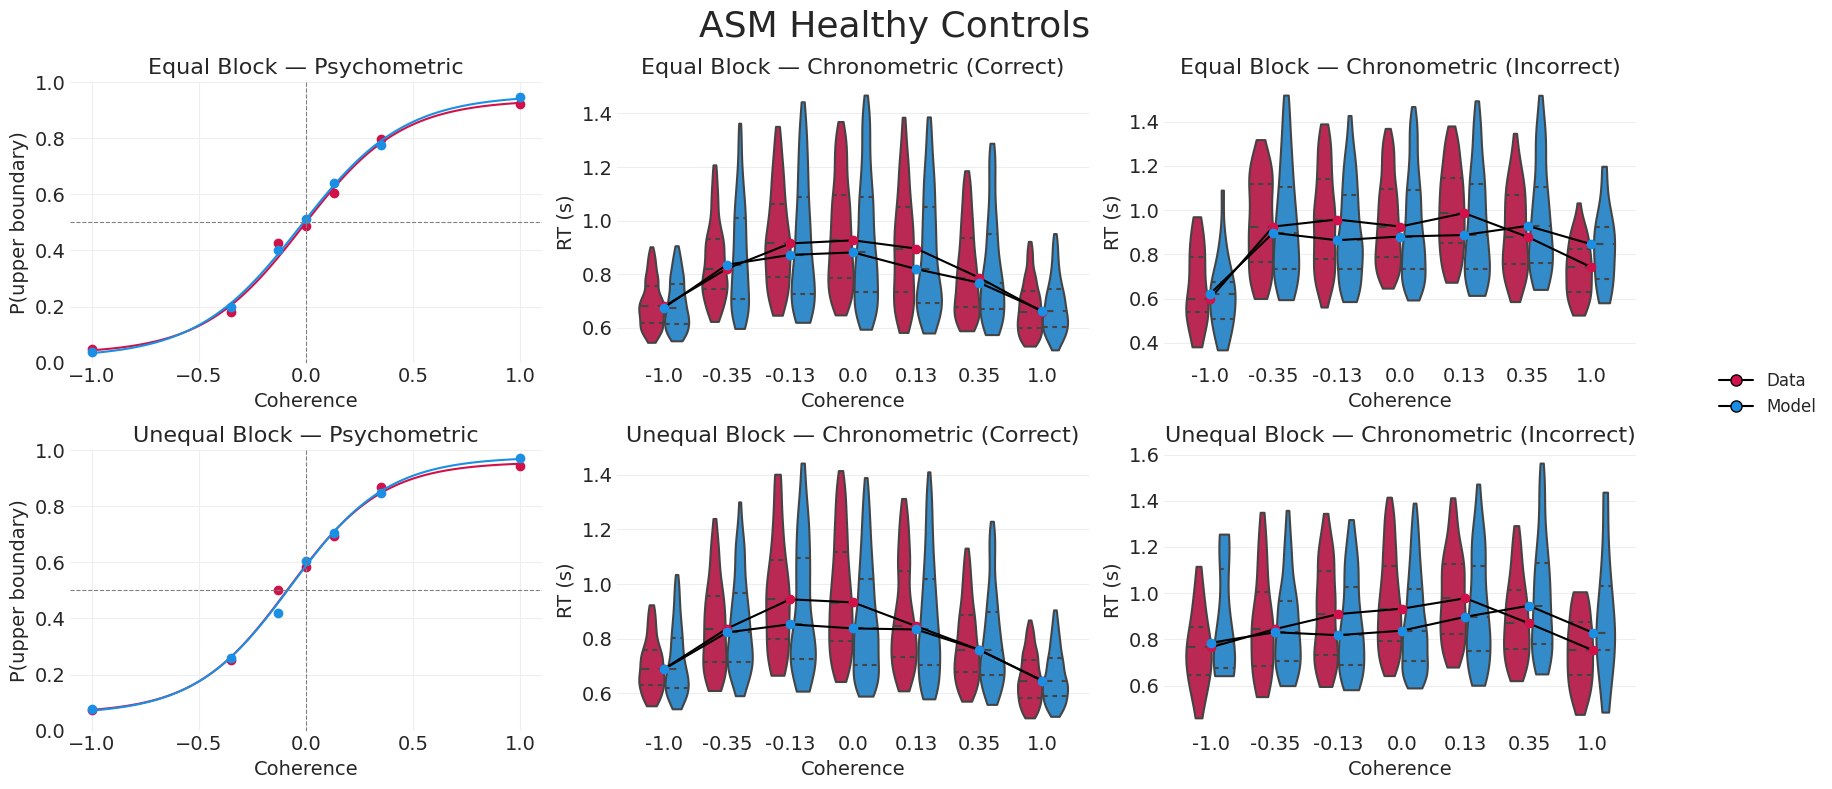

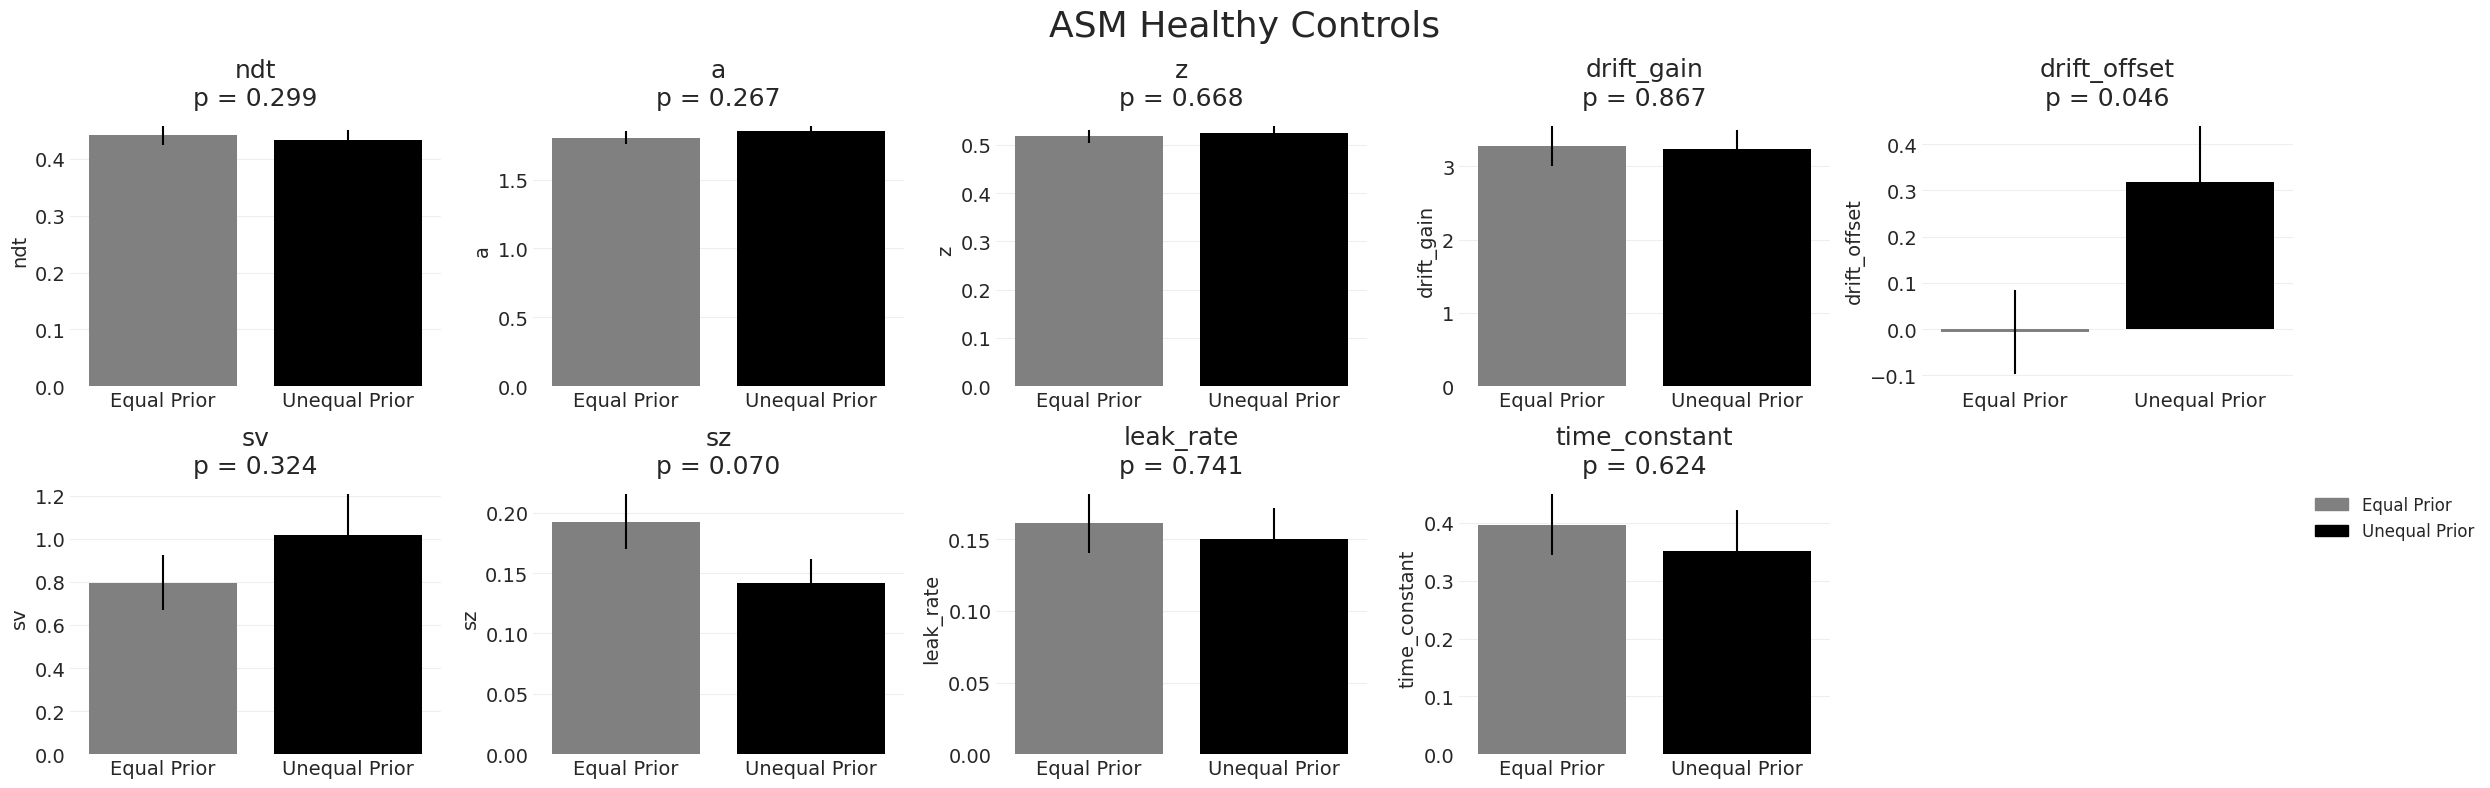

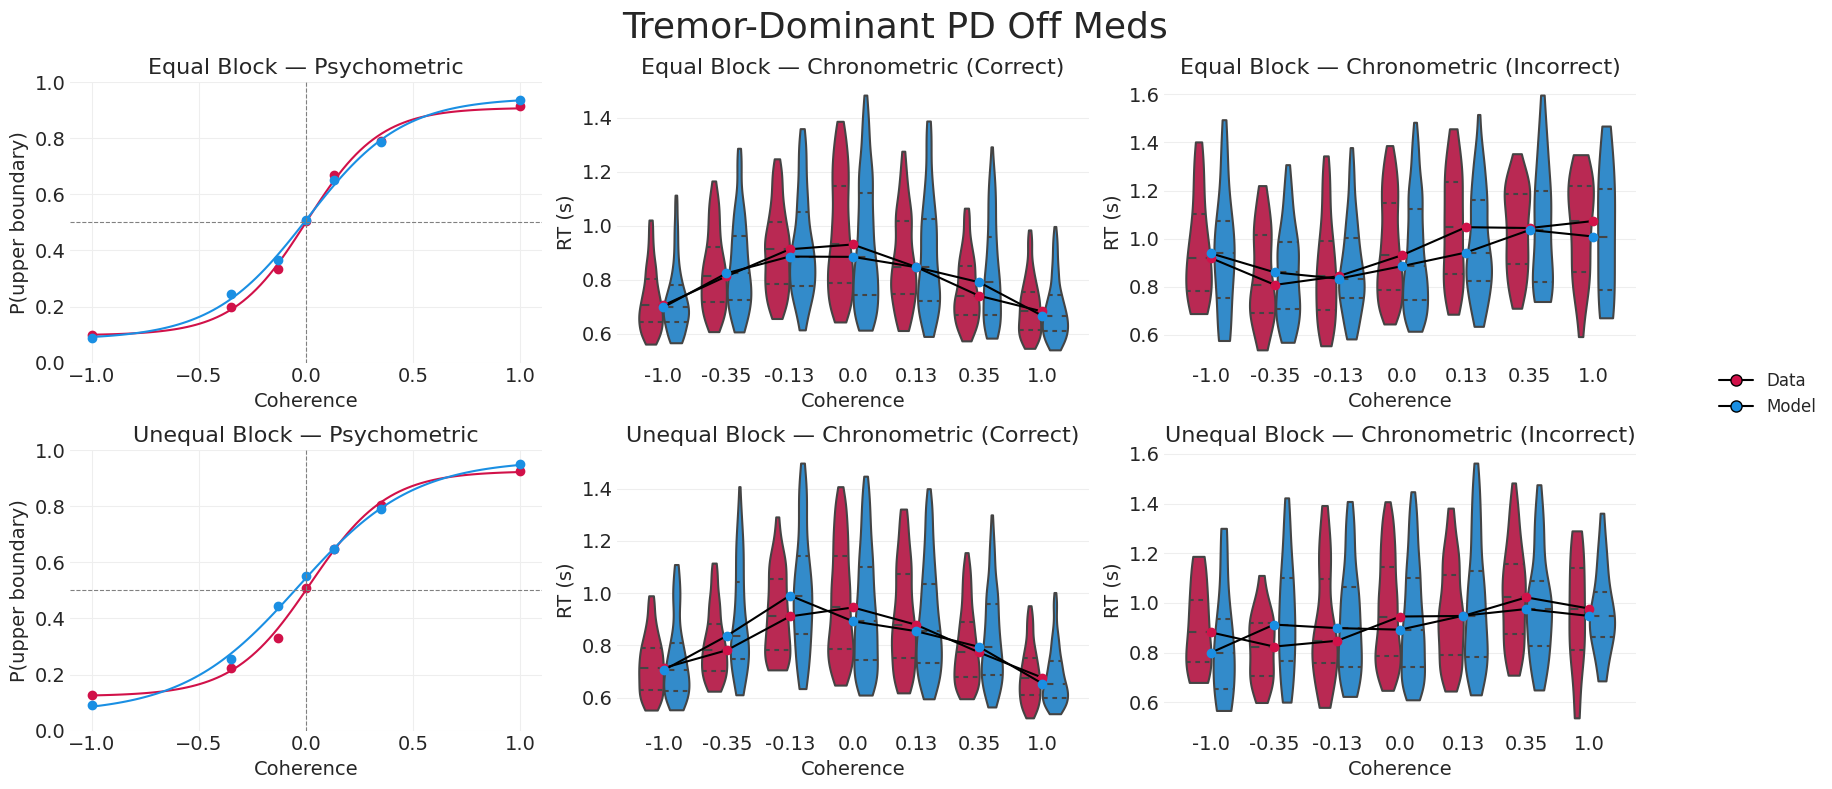

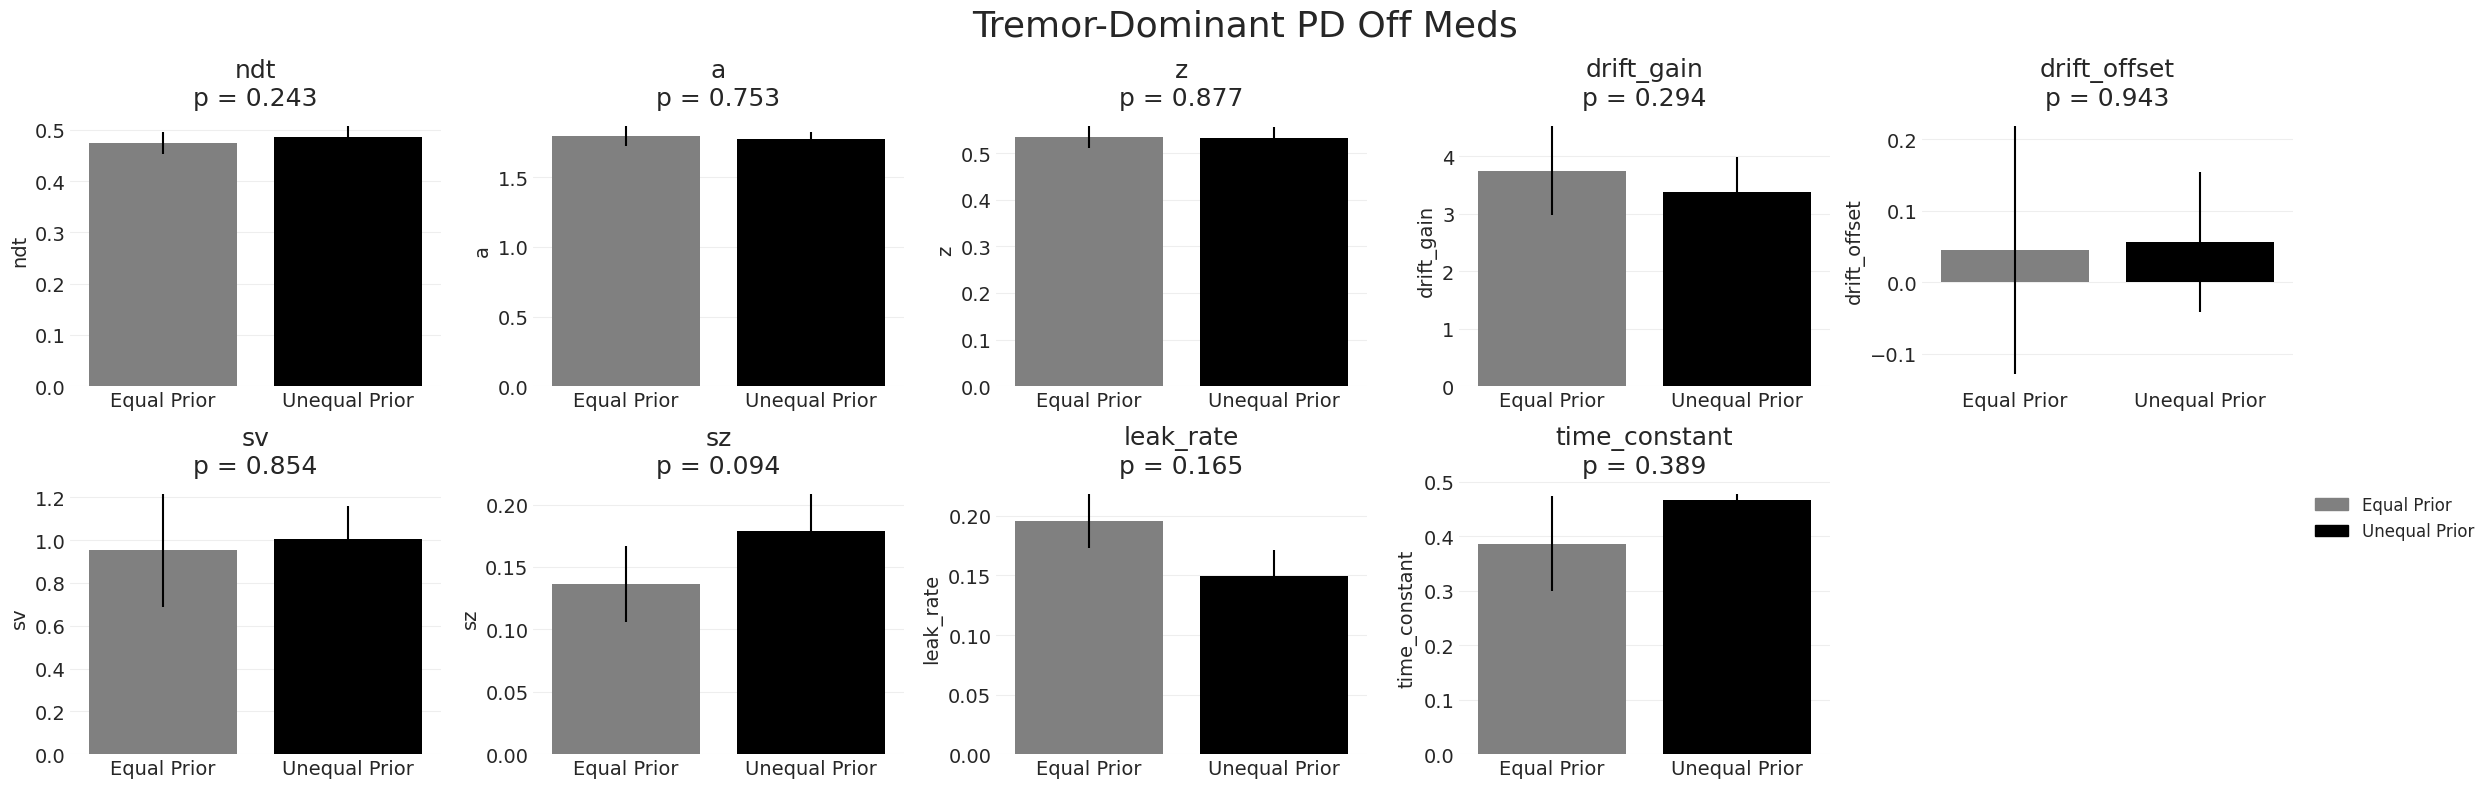

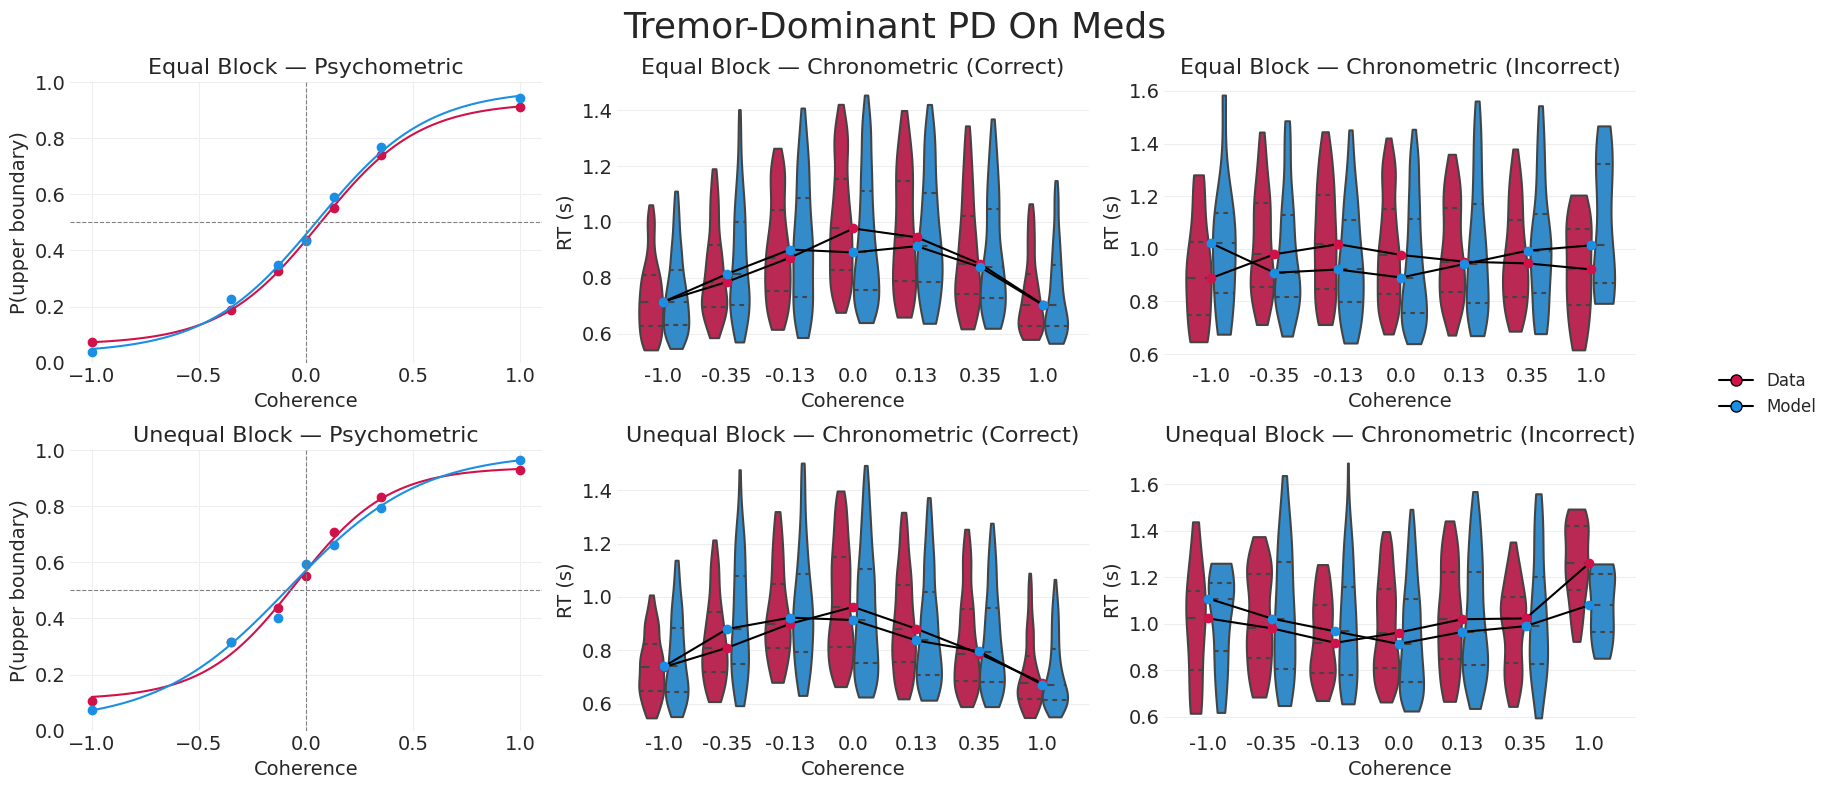

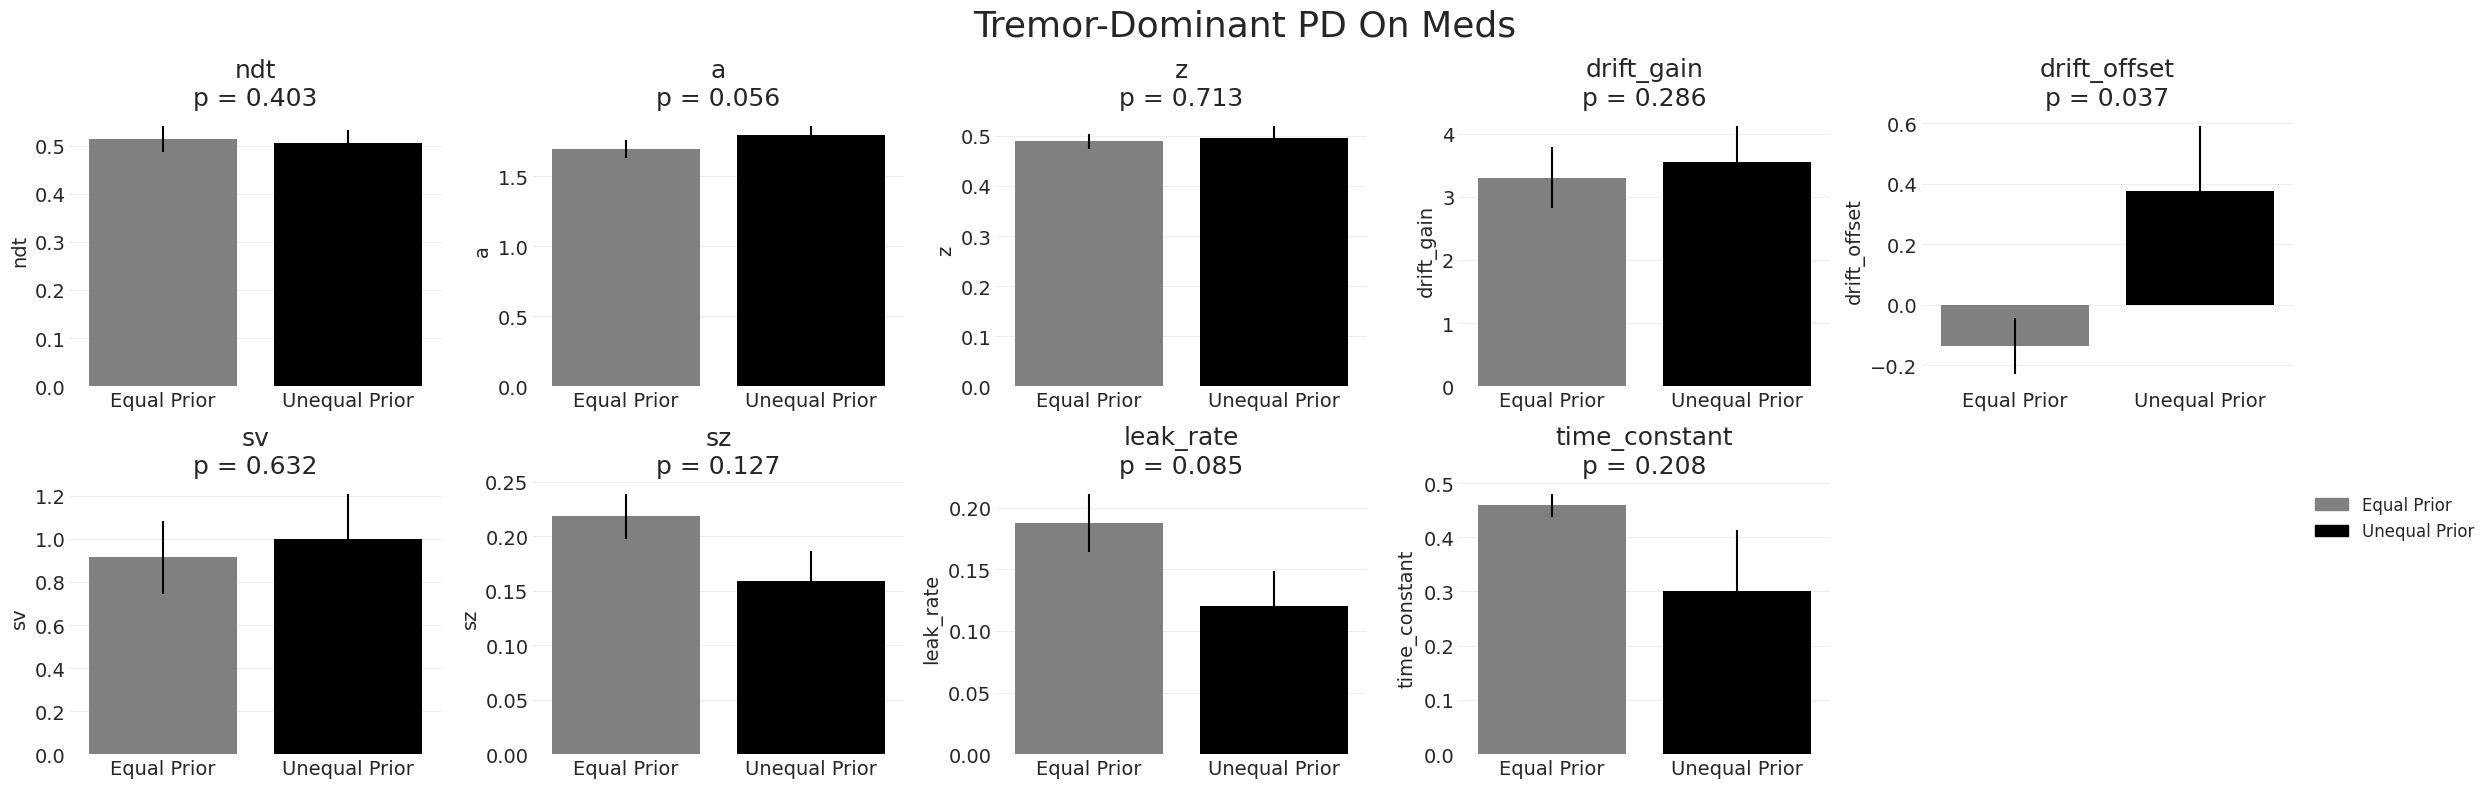

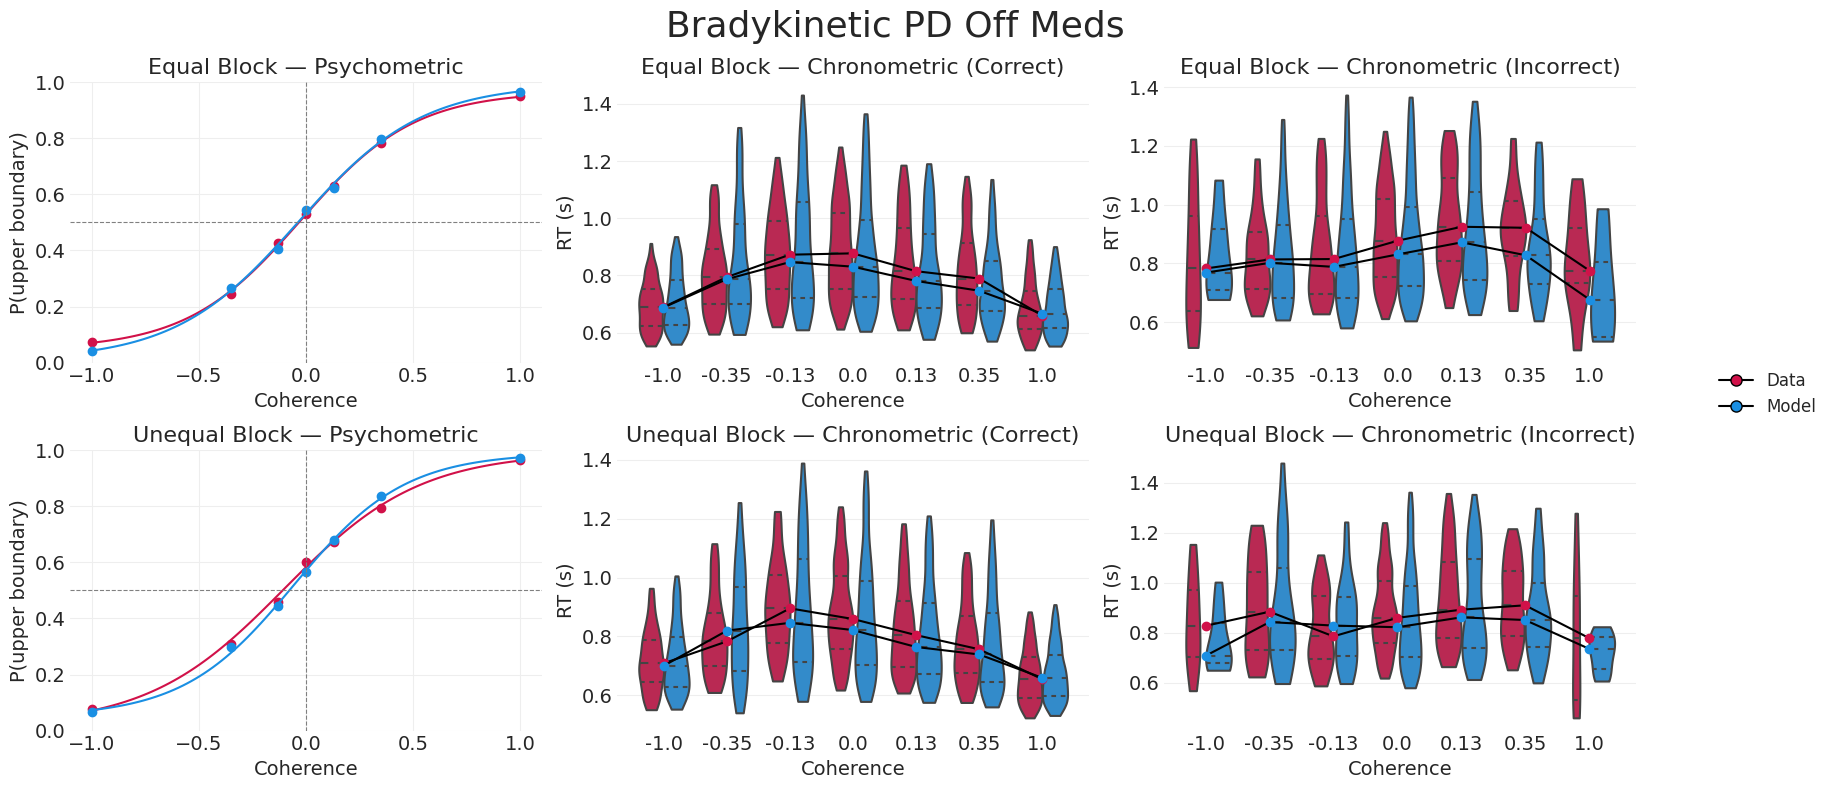

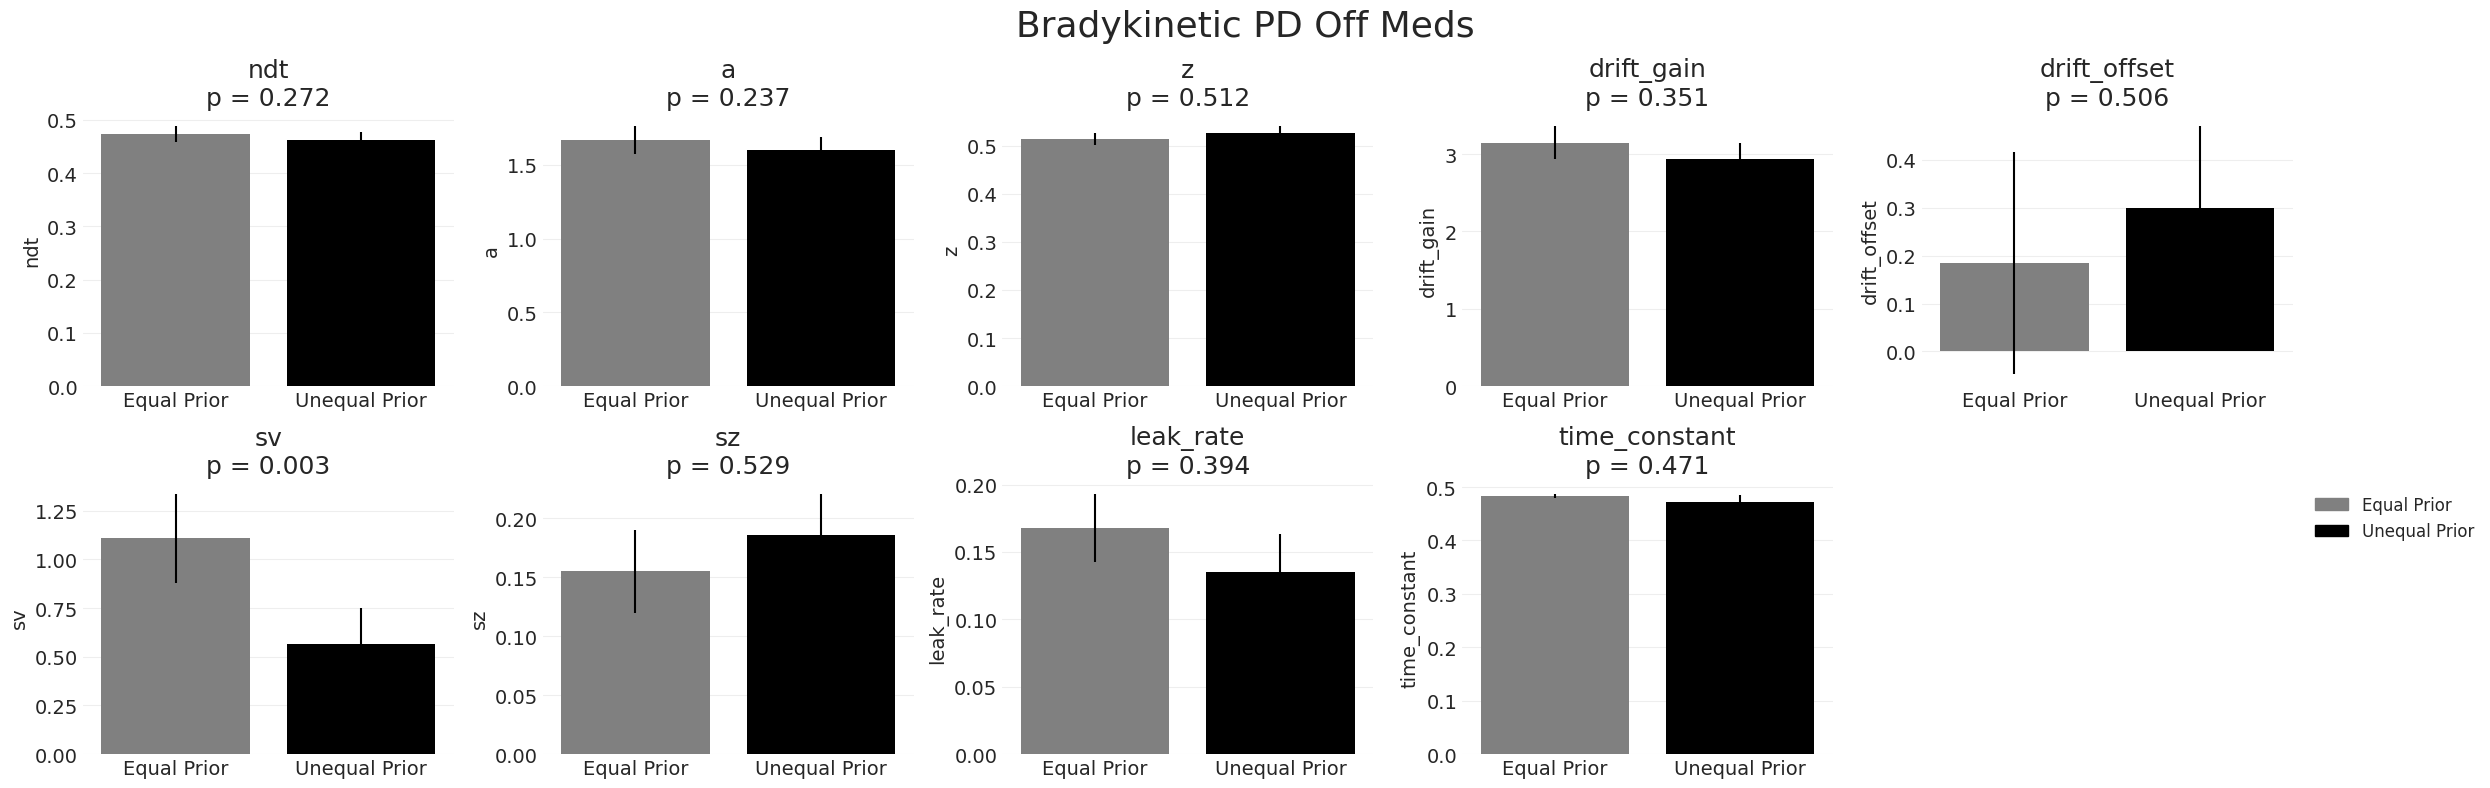

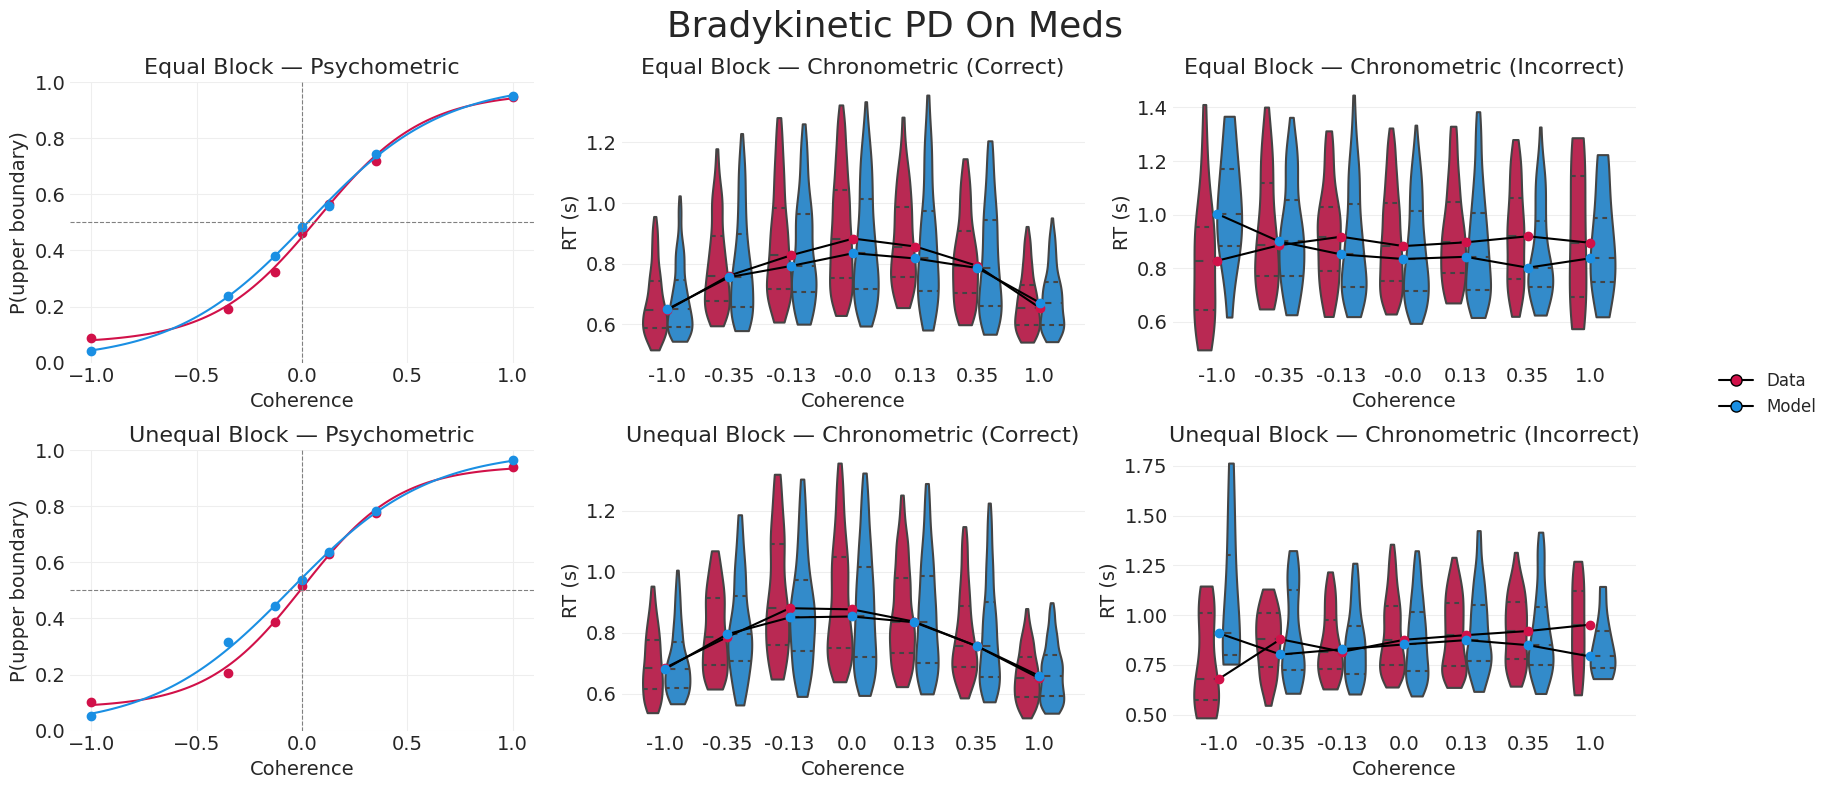

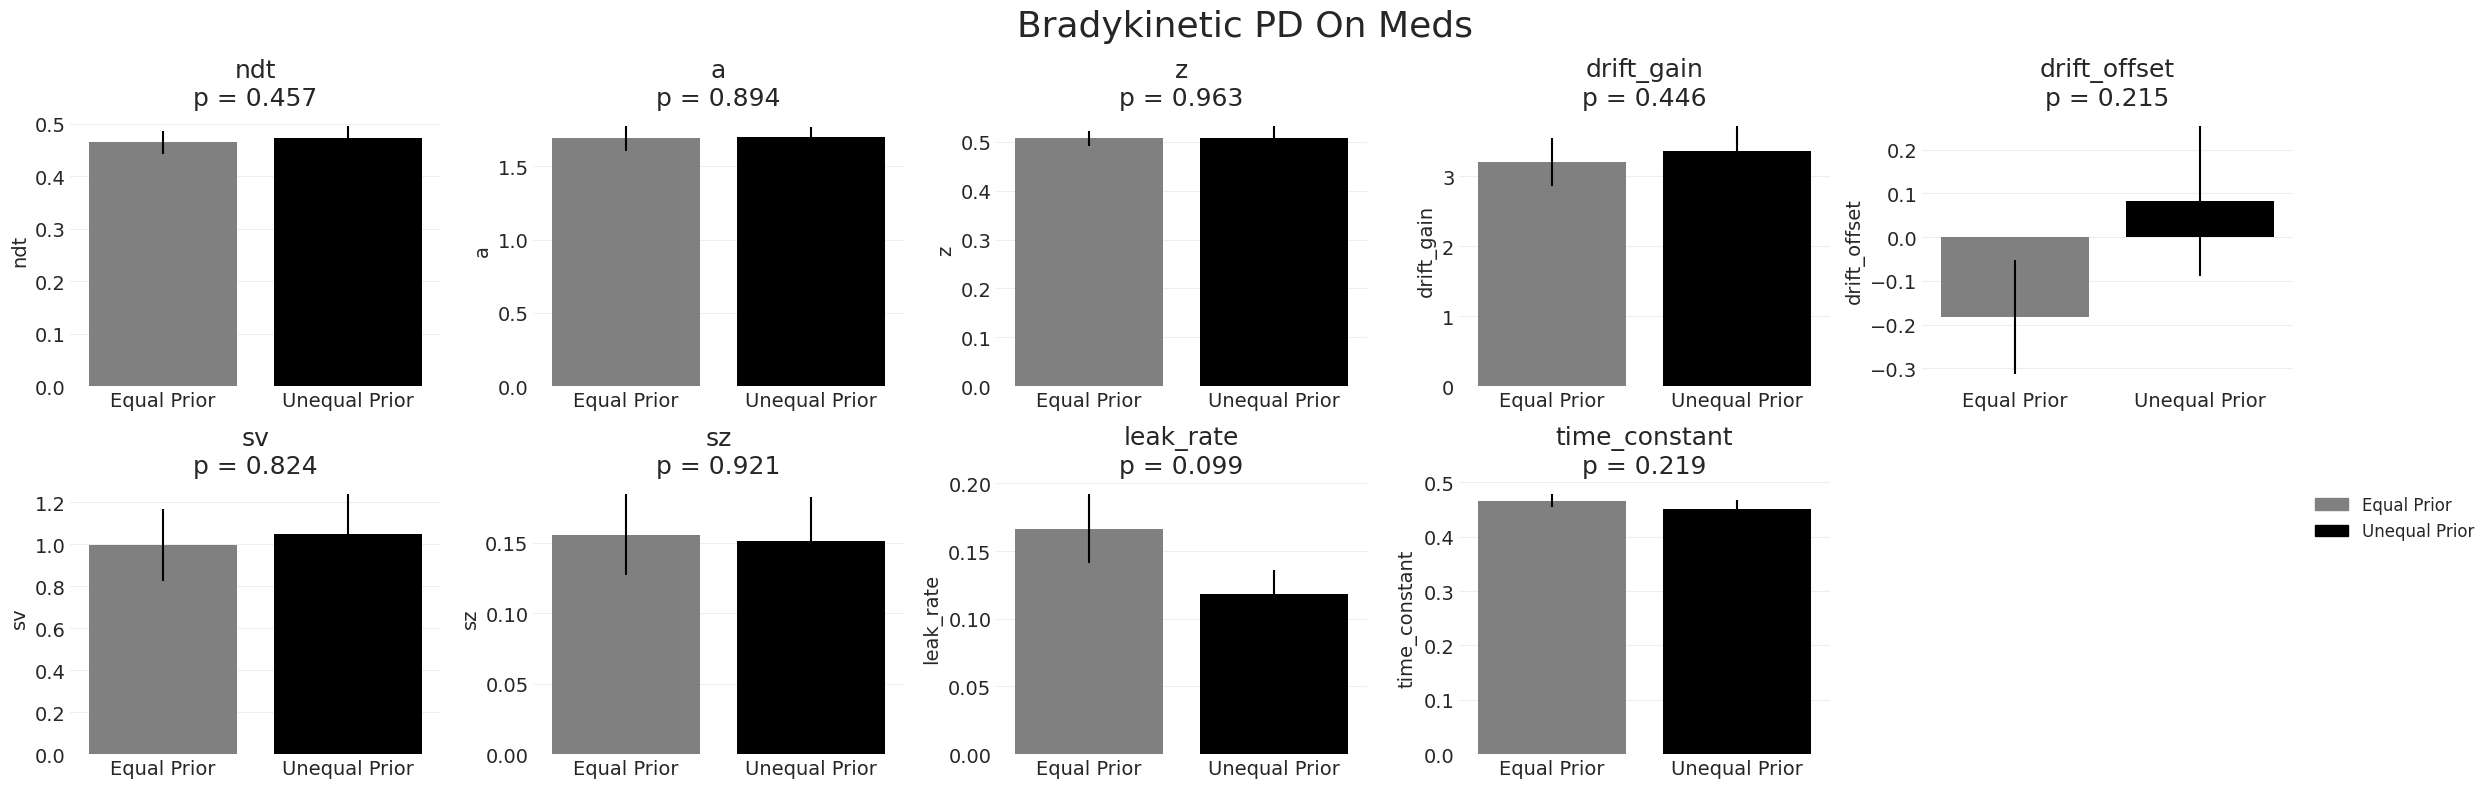

In [9]:
titles = [
    "ASM Healthy Controls",
    "Tremor-Dominant PD Off Meds",
    "Tremor-Dominant PD On Meds",
    "Bradykinetic PD Off Meds",
    "Bradykinetic PD On Meds"
]

figure_dict = {}

for group_dict, title in zip([asm_controls, trem_off_meds, trem_on_meds, brady_off_meds, brady_on_meds], titles):
    params, s_data, d_data = get_params_sdata_ddata(group_dict)
    behav_plot = plot_group_fits(d_data, s_data, summary_style="median", show_strip=False, title=title)
    param_plot = plot_param_comparison(params, model_name=title)
    figure_dict[title] = {"behavior": behav_plot, "parameter": param_plot}

## Export

In [10]:
params_rows = []
for model in model_files:
    session_id = model["job"]["session_id"]
    color = model["job"]["color"]
    params = model["results"]["parameters"]
    if not model["results"]["optimization_result"]["success"]:
        print(f"Skipping model for session {session_id} with color {color} due to failed optimization")
        continue
    row = {"session_id": session_id}
    row.update({f"{key}_prior_cond_{color}": value for key, value in params.items()})
    params_rows.append(row)


params_df = (
    pd.DataFrame(params_rows)
    .groupby("session_id", as_index=False)
    .first()
)

merged_df = metadata.merge(params_df, on="session_id", how="inner")

missing = set(metadata["session_id"]) - set(merged_df["session_id"])
if missing:
    raise ValueError(f"Missing params for {len(missing)} sessions: {missing}")

merged_df.to_csv(processed_dir / "processed_metadata_all_data_accu_60_ddm_params.csv", index=False)

In [11]:
# save figure_dict to power point with for each group: first slide group name, second slide behavior plot, third slide parameter plot
from pptx import Presentation
from pptx.util import Inches

def save_figures_to_ppt(figure_dict, ppt_path):
    prs = Presentation()
    for group_name, figs in figure_dict.items():
        # Add title slide
        title_slide_layout = prs.slide_layouts[0]
        slide = prs.slides.add_slide(title_slide_layout)
        title = slide.shapes.title
        title.text = group_name

        # Add behavior plot slide
        behav_slide_layout = prs.slide_layouts[5]  # Title Only layout
        slide = prs.slides.add_slide(behav_slide_layout)
        title = slide.shapes.title
        title.text = f"{group_name} - Behavior Fit"
        fig_path = f"{group_name}_behavior.png"
        figs["behavior"].savefig(fig_path, bbox_inches="tight")
        left = Inches(1)
        top = Inches(1.5)
        pic = slide.shapes.add_picture(fig_path, left, top, width=Inches(8))
        # remove the temporary figure file
        os.remove(fig_path)

        # Add parameter plot slide
        param_slide_layout = prs.slide_layouts[5]  # Title Only layout
        slide = prs.slides.add_slide(param_slide_layout)
        title = slide.shapes.title
        title.text = f"{group_name} - Parameter Comparison"
        fig_path = f"{group_name}_parameters.png"
        figs["parameter"].savefig(fig_path, bbox_inches="tight")
        left = Inches(1)
        top = Inches(1.5)
        pic = slide.shapes.add_picture(fig_path, left, top, width=Inches(8))
        # remove the temporary figure file
        os.remove(fig_path)

    prs.save(ppt_path)

save_figures_to_ppt(figure_dict, "dissemination/ddm/ddm_group_comparison.pptx")
